# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [45]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt

In [46]:

def multi_lorentz(x, A, h1, g1, x0_1, h2, g2, x0_2, h3, g3, x0_3):
    dip1 = h1 * (g1**2) / ((x - x0_1)**2 + g1**2)
    dip2 = h2 * (g2**2) / ((x - x0_2)**2 + g2**2)
    dip3 = h3 * (g3**2) / ((x - x0_3)**2 + g3**2)
    return A - (dip1 + dip2 + dip3)

In [62]:
# Load the file, skipping the first two header rows
df = pd.read_csv('./data/NewFile2.csv', skiprows=2, usecols=[0, 1, 2], names=['Sequence', 'CH1', 'CH2'])

# Access the columns as arrays for your fitting function
x = df['Sequence'].values
y1 = df['CH1'].values
y2 = df['CH2'].values

time = x * 0.05
y2_norm = y2 - min(y2)
y2_norm = y2_norm / max(y2_norm)


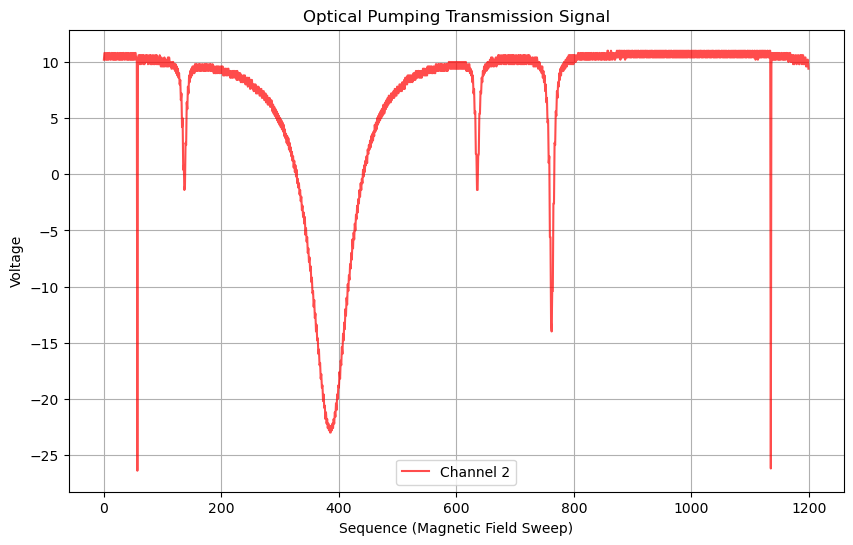

In [63]:
plt.figure(figsize=(10, 6))

# Plot CH1 and CH2
# plt.plot(df['Sequence'], df['CH1'], label='Channel 1', color='blue', alpha=0.7)
plt.plot(df['Sequence'], df['CH2'], label='Channel 2', color='red', alpha=0.7)
# plt.plot(time,y2_norm, label='Channel 2 normalized', color='red', alpha=0.7)

# Labels and formatting
plt.xlabel('Sequence (Magnetic Field Sweep)')
plt.ylabel('Voltage')
plt.title('Optical Pumping Transmission Signal')
plt.legend()
plt.grid(True)

plt.show()

In [72]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3"]
p0 = (1, 1, 0.3, 18, 0.3, 0.1, 32, 0.5, 0.1, 38)
lower_bound = (0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,2,2,100,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(multi_lorentz, time, y2_norm, p0=p0,bounds=bounds)
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.9886240197993578
h1 0.8925040015872012
g1 1.9330566902375534
x0_1 19.249687929197346
h2 0.30136318207211243
g2 0.15119482510018695
x0_2 31.77730730454403
h3 0.6409659552926527
g3 0.17967069764400215
x0_3 38.10508776310953


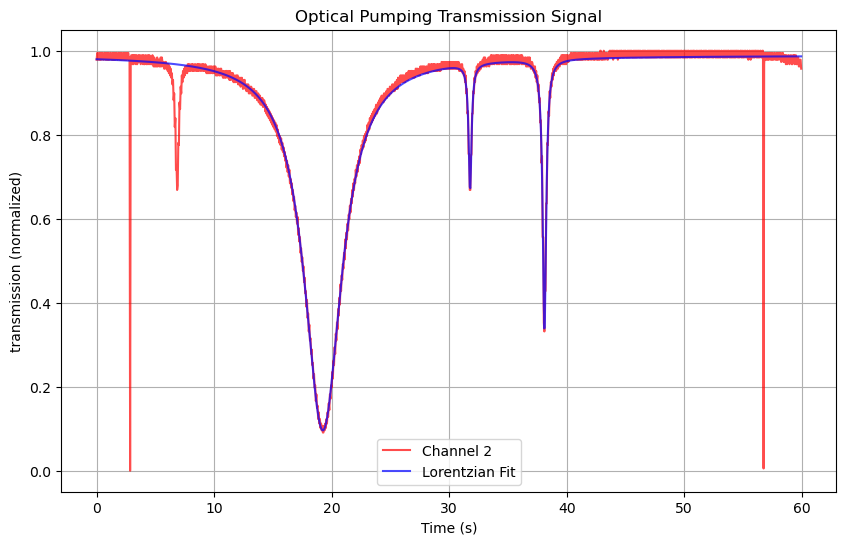

In [73]:
plt.figure(figsize=(10, 6))

# Plot CH1 and CH2
# plt.plot(df['Sequence'], df['CH1'], label='Channel 1', color='blue', alpha=0.7)
plt.plot(time, y2_norm, label='Channel 2', color='red', alpha=0.7)
plt.plot(time, multi_lorentz(time,*popt), label='Lorentzian Fit', color='blue', alpha=0.7)

# Labels and formatting
plt.xlabel('Time (s)')
plt.ylabel('transmission (normalized)')
plt.title('Optical Pumping Transmission Signal')
plt.legend()
plt.grid(True)

plt.show()